In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path = r"C:\Users\hp\Desktop\Trivikram\phase 2\Module 4 Unsupervised Learning\archive (1)\AIML Dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 6362620
Number of columns: 11


In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [6]:
df.dtypes

step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [7]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [8]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [9]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

step              0.0
type              0.0
amount            0.0
nameOrig          0.0
oldbalanceOrg     0.0
newbalanceOrig    0.0
nameDest          0.0
oldbalanceDest    0.0
newbalanceDest    0.0
isFraud           0.0
isFlaggedFraud    0.0
dtype: float64


In [10]:
missing_data = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_data

,Missing Values,Percentage
step,0,0.0
type,0,0.0
amount,0,0.0
nameOrig,0,0.0
oldbalanceOrg,0,0.0
newbalanceOrig,0,0.0
nameDest,0,0.0
oldbalanceDest,0,0.0
newbalanceDest,0,0.0
isFraud,0,0.0


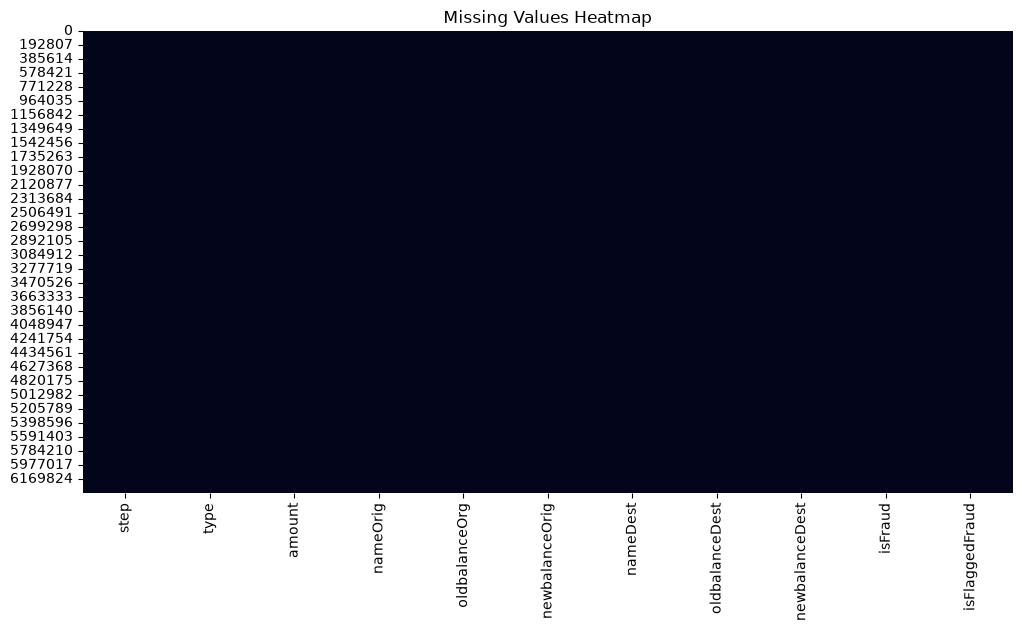

In [11]:
plt.figure(figsize=(12, 6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.show()

In [12]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [13]:
numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(list(numerical_columns))

Numerical columns:
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


In [14]:
for col in numerical_columns:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"\nColumn: {col}")
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))


Column: step
Lower Bound: -112.5
Upper Bound: 603.5
Number of Outliers: 102688

Column: amount
Lower Bound: -279608.29125
Upper Bound: 501719.33875
Number of Outliers: 338078

Column: oldbalanceOrg
Lower Bound: -160972.7625
Upper Bound: 268287.9375
Number of Outliers: 1112507

Column: newbalanceOrig
Lower Bound: -216387.615
Upper Bound: 360646.025
Number of Outliers: 1053391

Column: oldbalanceDest
Lower Bound: -1414555.06125
Upper Bound: 2357591.76875
Number of Outliers: 786135

Column: newbalanceDest
Lower Bound: -1667863.875
Upper Bound: 2779773.125
Number of Outliers: 738527

Column: isFraud
Lower Bound: 0.0
Upper Bound: 0.0
Number of Outliers: 8213

Column: isFlaggedFraud
Lower Bound: 0.0
Upper Bound: 0.0
Number of Outliers: 16


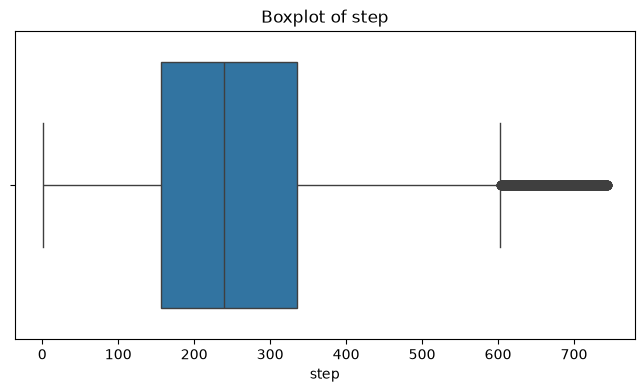

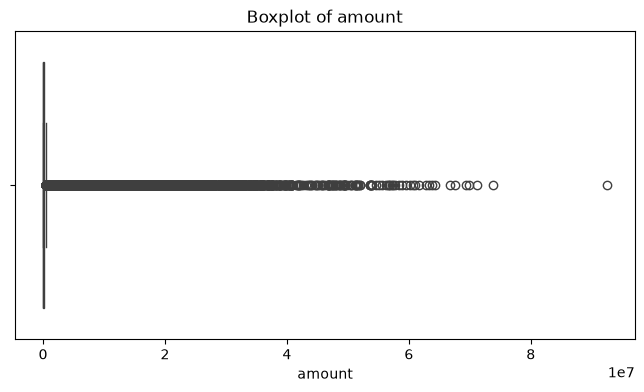

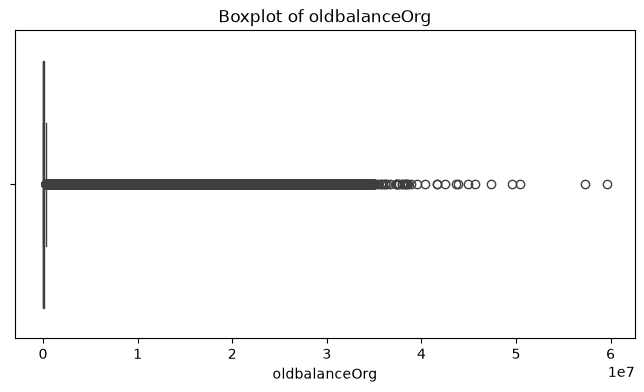

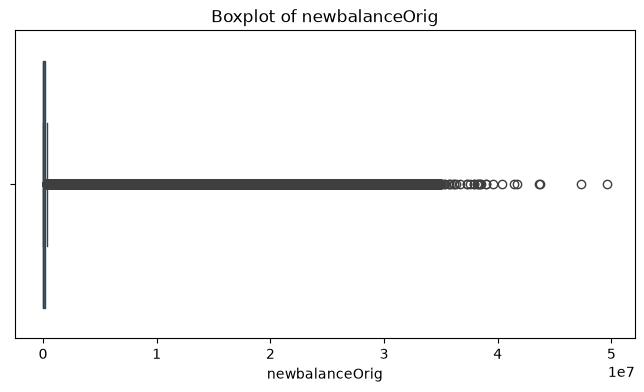

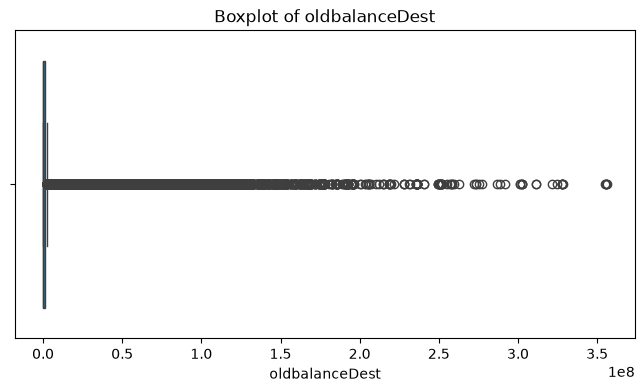

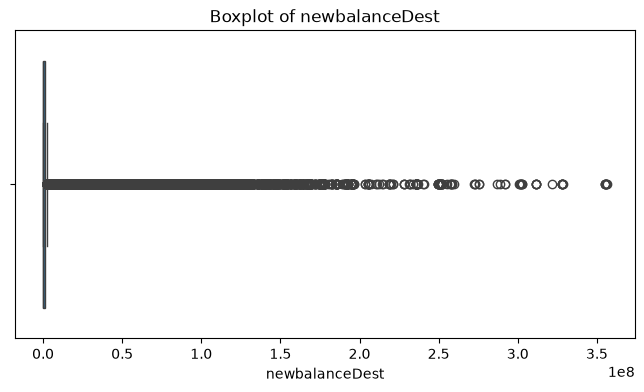

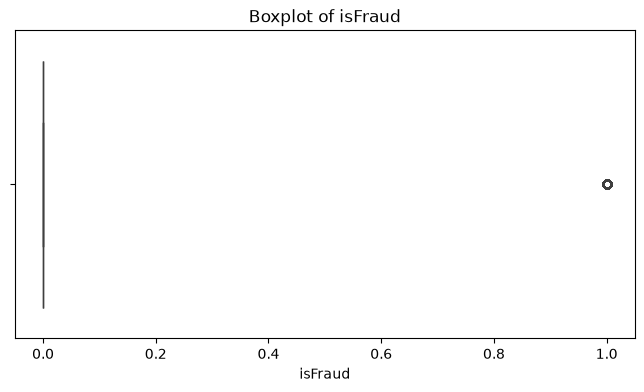

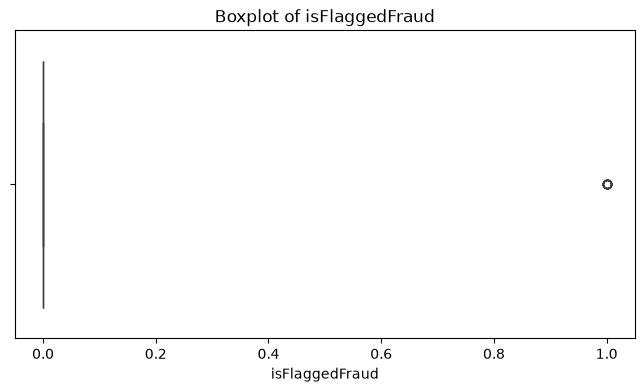

In [15]:
for col in numerical_columns:
    
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(x=df[col])
    
    plt.title(f"Boxplot of {col}")
    plt.show()

In [16]:
correlation = df[numerical_columns].corr()

correlation

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
step,1.000000,0.022373,-0.010058,-0.010299,0.027665,0.025888,0.031578,0.003277
amount,0.022373,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688,0.012295
oldbalanceOrg,-0.010058,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154,0.003835
newbalanceOrig,-0.010299,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148,0.003776
oldbalanceDest,0.027665,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885,-0.000513
newbalanceDest,0.025888,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535,-0.000529
isFraud,0.031578,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000,0.044109
isFlaggedFraud,0.003277,0.012295,0.003835,0.003776,-0.000513,-0.000529,0.044109,1.000000


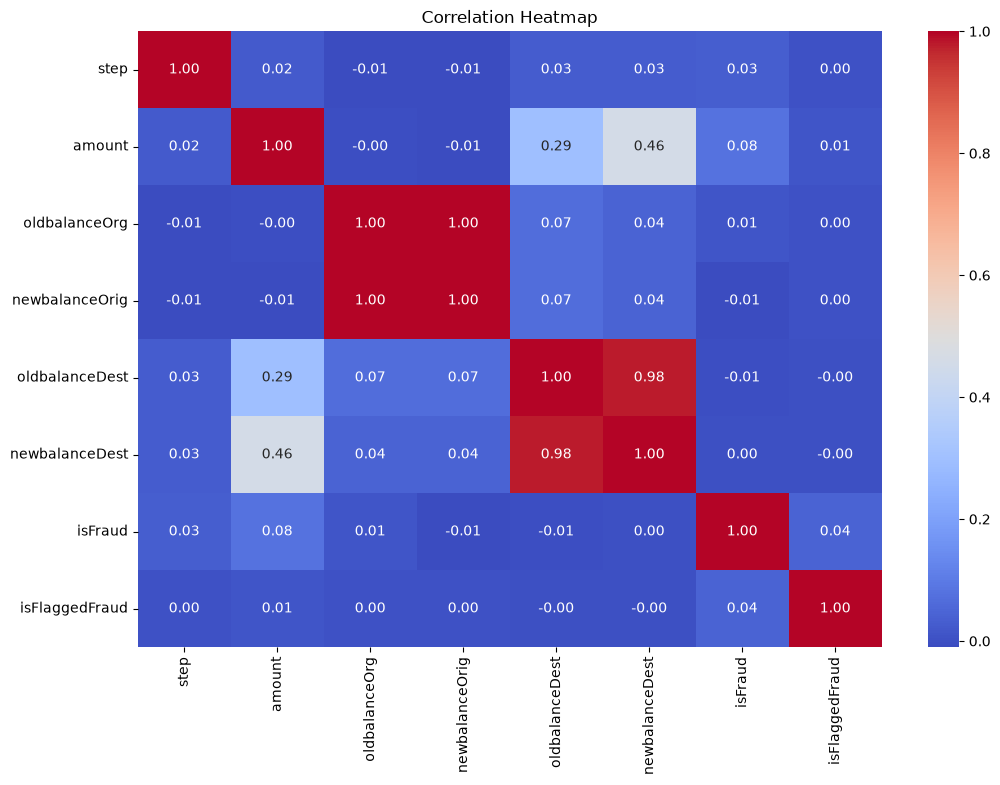

In [19]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [20]:
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print("\n", col)
    print(df[col].value_counts())

C:\Users\hp\AppData\Local\Temp\ipykernel_6428\4126613852.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns



 type
type
PAYMENT     1629609
CASH_OUT    1350392
TRANSFER     150141
CASH_IN       44613
DEBIT         22085
Name: count, dtype: int64

 nameOrig
nameOrig
C1677795071    3
C363736674     3
C1821711066    2
C1592228783    2
C13610224      2
              ..
C960748220     1
C737614907     1
C2025555227    1
C1586821392    1
C1666975703    1
Name: count, Length: 3194483, dtype: int64

 nameDest
nameDest
C832279283     27
C557041912     25
C404294128     25
C113096815     25
C1060830840    24
               ..
M1004141083     1
M313631875      1
M1594503804     1
M1739698995     1
M878113242      1
Name: count, Length: 2083734, dtype: int64


In [22]:
# Check categorical columns and number of unique values

categorical_columns = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_columns:
    print(f"{col}: {df[col].nunique():,} unique values")

C:\Users\hp\AppData\Local\Temp\ipykernel_6428\953096911.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object', 'category']).columns


type: 5 unique values
nameOrig: 3,194,483 unique values
nameDest: 2,083,734 unique values


In [23]:
# Show columns with very high number of unique values

for col in df.columns:
    unique_count = df[col].nunique()
    
    if unique_count > 1000:
        print(f"{col}: {unique_count:,} unique values")

amount: 2,693,785 unique values
nameOrig: 3,194,483 unique values
oldbalanceOrg: 376,833 unique values
newbalanceOrig: 646,479 unique values
nameDest: 2,083,734 unique values
oldbalanceDest: 1,233,715 unique values
newbalanceDest: 1,456,772 unique values


In [24]:
for col in df.columns:
    unique_count = df[col].nunique()
    percentage = (unique_count / len(df)) * 100
    
    if unique_count > 1000:
        print(f"{col}: {unique_count:,} unique values ({percentage:.2f}%)")

amount: 2,693,785 unique values (84.26%)
nameOrig: 3,194,483 unique values (99.93%)
oldbalanceOrg: 376,833 unique values (11.79%)
newbalanceOrig: 646,479 unique values (20.22%)
nameDest: 2,083,734 unique values (65.18%)
oldbalanceDest: 1,233,715 unique values (38.59%)
newbalanceDest: 1,456,772 unique values (45.57%)


In [26]:
for col in df.columns:
    unique_ratio = df[col].nunique() / len(df)
    
    if unique_ratio > 0.95:
        print(f"{col}: {unique_ratio:.2%} unique")

nameOrig: 99.93% unique


## UP to Step 18 done